# Referential Recovery i Customer Analytics nad Retail Store Sales skupom

Ovaj notebook analizira kvalitet podataka nad skupom `retail_store_sales.csv` kroz pristup koji kombinuje referentni katalog proizvoda, procenu oporavljivosti transakcija i customer-level feature engineering. Fokus je na tri ideje:

- izgradnja **referentnog kataloga proizvoda** direktno iz podataka,
- procena **oporavljivosti transakcija** na osnovu poslovnih pravila,
- izvođenje **customer-level feature engineering** atributa nad očišćenim podacima.

Na taj način dataset se ne posmatra samo kao skup prljavih redova, već kao sistem u kome možemo da proveravamo referentni integritet, vraćamo izgubljene vrednosti i gradimo sloj korisničke analitike.


## Plan rada

Analiza je organizovana u šest faza:

1. osnovni audit skupa podataka,
2. izgradnja internog product master-a,
3. provera referentnog i aritmetičkog integriteta,
4. analiza recoverability obrazaca i rule-based oporavak,
5. feature engineering nad datumima, popustima i kupcima,
6. poređenje kvaliteta pre i posle čišćenja.


In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid")


In [2]:
df = pd.read_csv("archive/retail_store_sales.csv")
df.head()


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,True
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,True
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,False
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NaN
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,False


## 1. Osnovni audit skupa podataka

Prvi korak je procena osnovne upotrebljivosti skupa: broj redova, tipovi, nedostajuće vrednosti, jedinstvenost identifikatora i vremenski opseg podataka.


In [3]:
df.shape


(12575, 11)

In [4]:
audit = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(2),
    "unique": df.nunique(dropna=False)
})
audit


,dtype,missing,missing_pct,unique
Transaction ID,str,0,0.00,12575
Customer ID,str,0,0.00,25
Category,str,0,0.00,8
Item,str,1213,9.65,201
Price Per Unit,float64,609,4.84,26
Quantity,float64,604,4.80,11
Total Spent,float64,604,4.80,228
Payment Method,str,0,0.00,3
Location,str,0,0.00,2
Transaction Date,str,0,0.00,1114


In [5]:
print("Duplikati redova:", df.duplicated().sum())
print("Duplikati Transaction ID:", df["Transaction ID"].duplicated().sum())
print("Broj jedinstvenih Customer ID:", df["Customer ID"].nunique())


Duplikati redova: 0
Duplikati Transaction ID: 0
Broj jedinstvenih Customer ID: 25


In [6]:
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")
df["Transaction Date"].agg(["min", "max"])


min   2022-01-01
max   2025-01-18
Name: Transaction Date, dtype: datetime64[us]

Već na početku se vidi nekoliko važnih stvari:

- identifikatori transakcija su potpuno jedinstveni,
- datumi su parsabilni i pokrivaju više godina,
- glavni problemi se nalaze u kolonama `Item`, `Price Per Unit`, `Quantity`, `Total Spent` i `Discount Applied`.

To je dobar signal da možemo da gradimo katalog i pravila oporavka bez bojazni da su osnovni identifikatori kompromitovani.


## 2. Interni product master kao referentni sloj

Pošto dataset sadrži statične cene artikala, možemo iz kompletnijih zapisa da napravimo **interni katalog proizvoda**. To je korisno jer kasnije omogućava da proverimo da li je kombinacija `Category -> Item -> Price` dosledna i da vratimo deo nedostajućih vrednosti.


In [7]:
product_master = (
    df.dropna(subset=["Category", "Item", "Price Per Unit"])
      .groupby(["Category", "Item"])["Price Per Unit"]
      .agg(lambda s: s.mode().iloc[0])
      .reset_index()
      .sort_values(["Category", "Item"])
)
product_master.head(15)


,Category,Item,Price Per Unit
0,Beverages,Item_10_BEV,18.5
1,Beverages,Item_11_BEV,20.0
2,Beverages,Item_12_BEV,21.5
3,Beverages,Item_13_BEV,23.0
4,Beverages,Item_14_BEV,24.5
5,Beverages,Item_15_BEV,26.0
6,Beverages,Item_16_BEV,27.5
7,Beverages,Item_17_BEV,29.0
8,Beverages,Item_18_BEV,30.5
9,Beverages,Item_19_BEV,32.0


In [8]:
master_summary = pd.DataFrame({
    "n_categories": [product_master["Category"].nunique()],
    "n_items": [product_master["Item"].nunique()],
    "unique_category_price_pairs": [product_master[["Category", "Price Per Unit"]].drop_duplicates().shape[0]],
    "duplicate_category_price_pairs": [product_master.duplicated(["Category", "Price Per Unit"]).sum()]
})
master_summary


,n_categories,n_items,unique_category_price_pairs,duplicate_category_price_pairs
0,8,200,200,0


Ako je `Category + Price` jednoznačno vezano za `Item`, onda dobijamo veoma korisno pravilo: iz poznate kategorije i cene možemo rekonstruisati nedostajući artikal. To je ovde jača tehnika nego u kafić dataset-u, jer je katalog bogatiji i pravilnije strukturisan.


## 3. Provera referentnog i aritmetičkog integriteta

Ovde proveravamo dve vrste konzistentnosti:

- **referentnu konzistentnost**: da li isti `Item` uvek pripada istoj kategoriji i istoj ceni,
- **aritmetičku konzistentnost**: da li važi `Total Spent = Quantity * Price Per Unit`.


In [9]:
item_integrity = (
    df.dropna(subset=["Item", "Category", "Price Per Unit"])
      .groupby("Item")
      .agg(category_n=("Category", "nunique"), price_n=("Price Per Unit", "nunique"))
)

print("Items sa više kategorija:", (item_integrity["category_n"] > 1).sum())
print("Items sa više cena:", (item_integrity["price_n"] > 1).sum())


Items sa više kategorija: 0
Items sa više cena: 0


In [10]:
mask = df[["Quantity", "Price Per Unit", "Total Spent"]].notna().all(axis=1)
arithmetic_conflicts = df.loc[mask].copy()
arithmetic_conflicts["expected_total"] = arithmetic_conflicts["Quantity"] * arithmetic_conflicts["Price Per Unit"]
arithmetic_conflicts = arithmetic_conflicts[~np.isclose(arithmetic_conflicts["Total Spent"], arithmetic_conflicts["expected_total"])]

print("Broj aritmetičkih konflikata:", len(arithmetic_conflicts))
arithmetic_conflicts.head()


Broj aritmetičkih konflikata: 0


,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied,expected_total


Važan nalaz je da dataset gotovo da nema kontradikcije kada su polja popunjena. To znači da je glavni problem više u **nepotpunosti transakcije** nego u pogrešnoj transakciji.


## 4. Recoverability analiza

Ovde uvodimo tehniku recoverability analize: umesto da gledamo samo koliko vrednosti nedostaje, merimo **koliko redova je moguće oporaviti** korišćenjem pravila.

Posebno nas zanimaju obrasci:

- `Item` nedostaje, ali su `Category` i `Price Per Unit` poznati,
- `Price Per Unit` nedostaje, ali je `Item` poznat,
- `Total Spent` nedostaje, ali su `Quantity` i `Price Per Unit` poznati,
- `Quantity` nedostaje, ali su `Total Spent` i `Price Per Unit` poznati.


In [11]:
missing_patterns = pd.DataFrame({
    "item_missing": df["Item"].isna(),
    "price_missing": df["Price Per Unit"].isna(),
    "quantity_missing": df["Quantity"].isna(),
    "total_missing": df["Total Spent"].isna(),
    "discount_missing": df["Discount Applied"].isna()
})
missing_patterns.value_counts().head(10)


item_missing  price_missing  quantity_missing  total_missing  discount_missing
False         False          False             False          False               7579
                                                              True                3783
True          True           False             False          False                404
              False          True              True           False                393
                                                              True                 211
              True           False             False          True                 205
Name: count, dtype: int64

In [12]:
recoverability = pd.Series({
    "Item iz Category+Price": int((df["Item"].isna() & df["Category"].notna() & df["Price Per Unit"].notna()).sum()),
    "Price iz Item": int((df["Price Per Unit"].isna() & df["Item"].notna()).sum()),
    "Total iz Quantity+Price": int((df["Total Spent"].isna() & df["Quantity"].notna() & df["Price Per Unit"].notna()).sum()),
    "Quantity iz Total+Price": int((df["Quantity"].isna() & df["Total Spent"].notna() & df["Price Per Unit"].notna()).sum())
}).sort_values(ascending=False)
recoverability


Item iz Category+Price     604
Price iz Item                0
Total iz Quantity+Price      0
Quantity iz Total+Price      0
dtype: int64

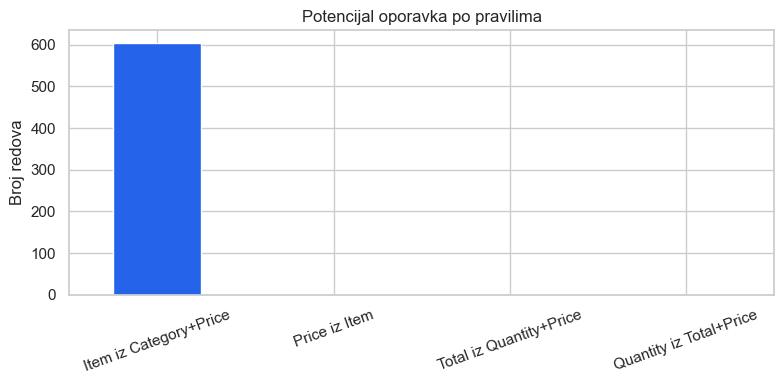

In [13]:
plt.figure(figsize=(8, 4))
recoverability.plot(kind="bar", color="#2563eb")
plt.title("Potencijal oporavka po pravilima")
plt.ylabel("Broj redova")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## 5. Rule-based oporavak transakcija

Na osnovu product master-a i aritmetike transakcije radimo kontrolisani recovery. Svaka popravka zasniva se na transparentnom pravilu, bez proizvoljnog popunjavanja vrednosti.


In [14]:
clean = df.copy()

item_to_price = product_master.drop_duplicates("Item").set_index("Item")["Price Per Unit"].to_dict()
cat_price_to_item = product_master.drop_duplicates(["Category", "Price Per Unit"]).set_index(["Category", "Price Per Unit"])["Item"].to_dict()

repair_log = {}

mask = clean["Price Per Unit"].isna() & clean["Item"].notna()
repair_log["price_from_item"] = int(mask.sum())
clean.loc[mask, "Price Per Unit"] = clean.loc[mask, "Item"].map(item_to_price)

mask = clean["Item"].isna() & clean["Category"].notna() & clean["Price Per Unit"].notna()
item_values = pd.Series(list(zip(clean.loc[mask, "Category"], clean.loc[mask, "Price Per Unit"])), index=clean.loc[mask].index).map(cat_price_to_item)
repair_log["item_from_category_price"] = int(item_values.notna().sum())
clean.loc[item_values.index, "Item"] = item_values

mask = clean["Total Spent"].isna() & clean["Quantity"].notna() & clean["Price Per Unit"].notna()
repair_log["total_from_quantity_price"] = int(mask.sum())
clean.loc[mask, "Total Spent"] = clean.loc[mask, "Quantity"] * clean.loc[mask, "Price Per Unit"]

mask = clean["Quantity"].isna() & clean["Total Spent"].notna() & clean["Price Per Unit"].notna()
ratio = clean.loc[mask, "Total Spent"] / clean.loc[mask, "Price Per Unit"]
valid_ratio = ratio.round(10).isin([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0])
repair_log["quantity_from_total_price"] = int(valid_ratio.sum())
clean.loc[ratio.index[valid_ratio], "Quantity"] = ratio[valid_ratio]

repair_log


{'price_from_item': 0,
 'item_from_category_price': 604,
 'total_from_quantity_price': 0,
 'quantity_from_total_price': 0}

In [15]:
quality_compare = pd.DataFrame({
    "before_valid": [
        df["Item"].notna().sum(),
        df["Price Per Unit"].notna().sum(),
        df["Quantity"].notna().sum(),
        df["Total Spent"].notna().sum(),
        df["Discount Applied"].notna().sum(),
    ],
    "after_valid": [
        clean["Item"].notna().sum(),
        clean["Price Per Unit"].notna().sum(),
        clean["Quantity"].notna().sum(),
        clean["Total Spent"].notna().sum(),
        clean["Discount Applied"].notna().sum(),
    ]
}, index=["Item", "Price Per Unit", "Quantity", "Total Spent", "Discount Applied"])

quality_compare["before_pct"] = (quality_compare["before_valid"] / len(df) * 100).round(2)
quality_compare["after_pct"] = (quality_compare["after_valid"] / len(df) * 100).round(2)
quality_compare["gain"] = quality_compare["after_valid"] - quality_compare["before_valid"]
quality_compare


,before_valid,after_valid,before_pct,after_pct,gain
Item,11362,11966,90.35,95.16,604
Price Per Unit,11966,11966,95.16,95.16,0
Quantity,11971,11971,95.20,95.20,0
Total Spent,11971,11971,95.20,95.20,0
Discount Applied,8376,8376,66.61,66.61,0


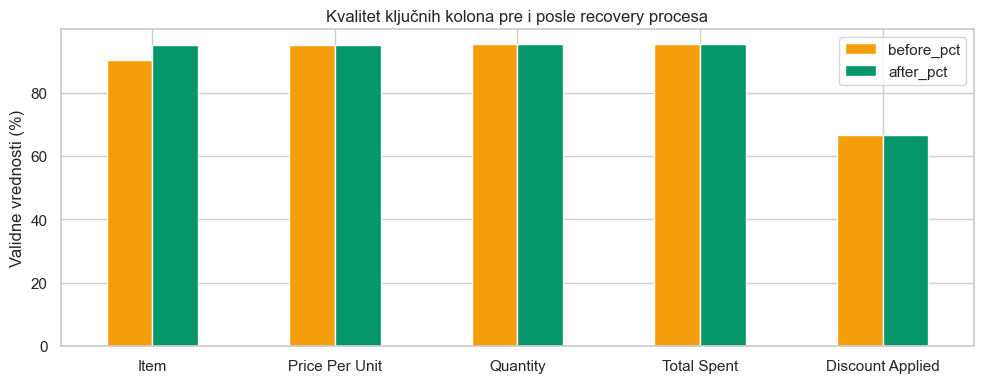

In [16]:
quality_compare[["before_pct", "after_pct"]].plot(kind="bar", figsize=(10, 4), color=["#f59e0b", "#059669"])
plt.title("Kvalitet ključnih kolona pre i posle recovery procesa")
plt.ylabel("Validne vrednosti (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Kod ovog skupa najveći dobitak očekujemo kod kolone `Item`, jer je upravo ona često oporavljiva iz `Category + Price`. To je primer kako **referentni integritet** može da posluži kao tehnika čišćenja, a ne samo kao tehnika validacije.


## 6. Feature engineering nad očišćenim podacima

Pošto je dataset retail orijentisan, ovde uvodimo dve nove grupe atributa:

- **vremenske atribute**: godina, mesec, dan u nedelji, vikend,
- **customer analytics atribute**: recency, frequency, monetary i aproksimaciju customer lifetime value.

Pored toga, `Discount Applied` tretiramo kao trostanjsku promenljivu: `True`, `False` i `Unknown`, umesto da ga nasilno imputiramo.


In [17]:
clean["Discount Status"] = clean["Discount Applied"].astype("string").fillna("Unknown")
clean["Year"] = clean["Transaction Date"].dt.year
clean["Month"] = clean["Transaction Date"].dt.month
clean["MonthName"] = clean["Transaction Date"].dt.month_name()
clean["DayOfWeek"] = clean["Transaction Date"].dt.day_name()
clean["Weekend"] = clean["Transaction Date"].dt.dayofweek.isin([5, 6])
clean[["Discount Status", "Year", "MonthName", "DayOfWeek", "Weekend"]].head()


,Discount Status,Year,MonthName,DayOfWeek,Weekend
0,True,2024,April,Monday,False
1,True,2023,July,Sunday,True
2,False,2022,October,Wednesday,False
3,Unknown,2022,May,Saturday,True
4,False,2022,October,Sunday,True


In [18]:
customer_features = (
    clean.dropna(subset=["Total Spent"])
         .groupby("Customer ID")
         .agg(
             recency_days=("Transaction Date", lambda s: (clean["Transaction Date"].max() - s.max()).days),
             frequency=("Transaction ID", "count"),
             monetary=("Total Spent", "sum"),
             avg_basket=("Total Spent", "mean"),
             active_years=("Year", "nunique")
         )
)
customer_features["clv_proxy"] = (customer_features["frequency"] * customer_features["avg_basket"]).round(2)
customer_features.sort_values("clv_proxy", ascending=False).head(10)


,recency_days,frequency,monetary,avg_basket,active_years,clv_proxy
Customer ID,,,,,,
CUST_24,0,519,68452.0,131.892100,4,68452.0
CUST_08,1,507,67351.5,132.843195,4,67351.5
CUST_05,4,516,66974.5,129.795543,4,66974.5
CUST_16,2,494,65570.5,132.733806,4,65570.5
CUST_13,0,508,65037.0,128.025591,4,65037.0
CUST_23,4,481,64507.0,134.110187,4,64507.0
CUST_10,0,481,63155.5,131.300416,4,63155.5
CUST_15,1,501,63117.5,125.983034,4,63117.5
CUST_21,3,476,62933.0,132.212185,4,62933.0


In [19]:
customer_features.describe().T


,count,mean,std,min,25%,50%,75%,max
recency_days,25.0,1.920000,2.080064,0.000000,0.000000,1.000000,3.000000,7.000000
frequency,25.0,478.840000,20.705635,446.000000,461.000000,478.000000,494.000000,519.000000
monetary,25.0,62082.840000,2933.820681,57155.500000,60694.500000,61533.000000,63155.500000,68452.000000
avg_basket,25.0,129.685023,3.815533,121.095876,127.012222,129.888412,132.733806,136.347534
active_years,25.0,4.000000,0.000000,4.000000,4.000000,4.000000,4.000000,4.000000
clv_proxy,25.0,62082.840000,2933.820681,57155.500000,60694.500000,61533.000000,63155.500000,68452.000000


RFM i `clv_proxy` nisu ovde krajnji cilj modeliranja, već demonstracija da se posle poboljšanja kvaliteta podataka mogu graditi smisleni customer-level atributi. To je korak koji se često preskače u čistim EDA radovima, a zapravo pokazuje stvarnu vrednost čišćenja.


## 7. Poslovna analiza nad očišćenim podacima

Sada kada je transakcioni sloj stabilniji, možemo da pogledamo kako se prodaja raspoređuje po kategorijama, kanalima i kupcima.


In [20]:
category_summary = (
    clean.dropna(subset=["Total Spent"])
         .groupby("Category")
         .agg(
             transactions=("Transaction ID", "count"),
             total_revenue=("Total Spent", "sum"),
             avg_ticket=("Total Spent", "mean")
         )
         .sort_values("total_revenue", ascending=False)
)
category_summary


,transactions,total_revenue,avg_ticket
Category,,,
Butchers,1496,208118.0,139.116310
Electric household essentials,1516,203813.5,134.441623
Beverages,1496,197047.5,131.716243
Furniture,1525,195310.0,128.072131
Food,1507,194812.0,129.271400
Computers and electric accessories,1477,190692.5,129.107989
Patisserie,1441,182165.5,126.416031
Milk Products,1513,180112.0,119.042961


In [21]:
channel_discount = pd.crosstab(clean["Location"], clean["Discount Status"], normalize="index").round(3)
channel_discount


Discount Status,False,True,Unknown
Location,,,
In-store,0.330,0.333,0.337
Online,0.331,0.338,0.331


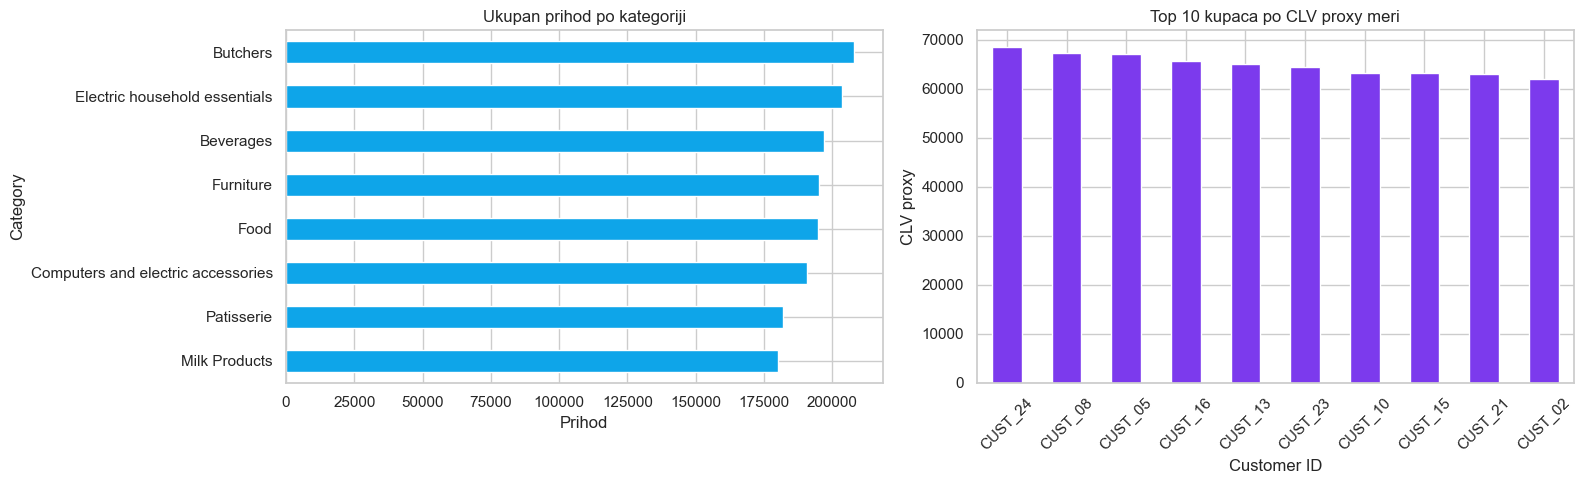

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

category_summary["total_revenue"].sort_values().plot(kind="barh", ax=axes[0], color="#0ea5e9")
axes[0].set_title("Ukupan prihod po kategoriji")
axes[0].set_xlabel("Prihod")

customer_features["clv_proxy"].sort_values(ascending=False).head(10).plot(kind="bar", ax=axes[1], color="#7c3aed")
axes[1].set_title("Top 10 kupaca po CLV proxy meri")
axes[1].set_ylabel("CLV proxy")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


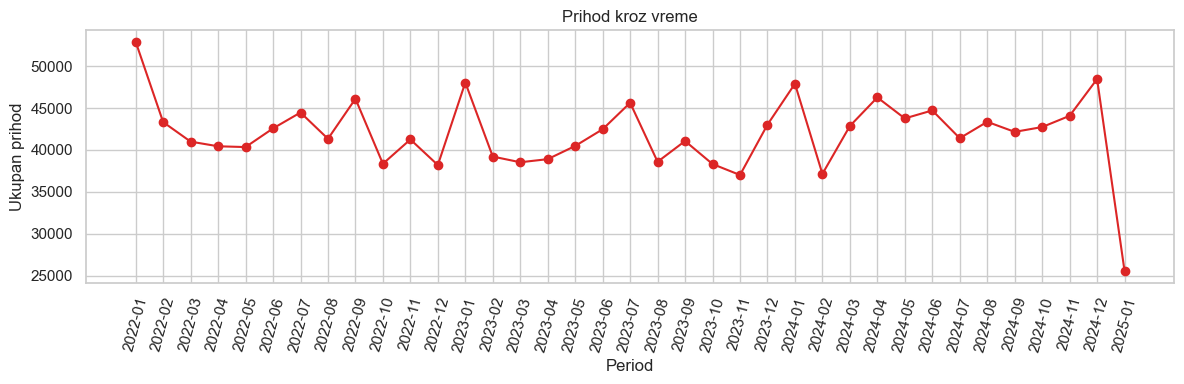

In [23]:
monthly_revenue = (
    clean.dropna(subset=["Total Spent"])
         .groupby(["Year", "Month"])["Total Spent"]
         .sum()
         .reset_index()
)
monthly_revenue["YearMonth"] = monthly_revenue["Year"].astype(str) + "-" + monthly_revenue["Month"].astype(str).str.zfill(2)

plt.figure(figsize=(12, 4))
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Total Spent"], marker="o", color="#dc2626")
plt.title("Prihod kroz vreme")
plt.xlabel("Period")
plt.ylabel("Ukupan prihod")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


## Zaključak

Ovaj skup podataka je dobar primer situacije u kojoj čišćenje ne treba posmatrati samo kao popunjavanje praznina, već kao **rekonstrukciju sistema referenci**. Kroz product master i rule-based recovery pokazano je da je moguće:

- proveriti integritet `Category -> Item -> Price` odnosa,
- proceniti koji deo transakcija je oporavljiv,
- vratiti deo izgubljenih vrednosti bez agresivne imputacije,
- preći sa row-level čišćenja na customer-level feature engineering.

Najvažnija poruka ovog rada je da kvalitet podataka u retail transakcijama nije važan samo zbog lepšeg EDA prikaza, već zato što direktno određuje da li možemo da gradimo pouzdane metrike kupaca, prihoda i ponašanja po kanalima prodaje.
